In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ds_salaries.csv to ds_salaries.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ds_salaries.csv")
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [ ]:
df.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


In [ ]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

In [ ]:
df_cleaned = df.drop(columns=["salary", "salary_currency", "employee_residence"])
df_cleaned.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,79833,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,0,JP,S
2,2020,SE,FT,Big Data Engineer,109024,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,50,US,L


In [ ]:
df_cleaned = df_cleaned.drop_duplicates()

In [ ]:
df_cleaned.groupby("job_title")["salary_in_usd"].mean().round(2).sort_values(ascending=False).head(10)

,salary_in_usd
job_title,
Data Analytics Lead,405000.00
Principal Data Engineer,328333.33
Financial Data Analyst,275000.00
Principal Data Scientist,215242.43
Director of Data Science,195074.00
Data Architect,177873.91
Applied Data Scientist,175655.00
Analytics Engineer,175000.00
Data Specialist,165000.00


In [ ]:
df_cleaned.groupby("experience_level")["salary_in_usd"].mean().round(2).sort_values(ascending=False)

,salary_in_usd
experience_level,
EX,199392.04
SE,138374.88
MI,87793.00
EN,61643.32


In [ ]:
df_cleaned["company_location"].value_counts().head(10)

,count
company_location,
US,318
GB,46
CA,28
DE,27
IN,24
FR,15
ES,14
GR,10
JP,6


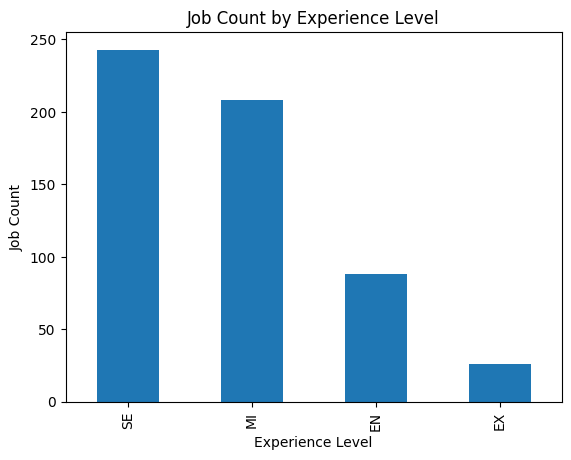

In [ ]:
import matplotlib.pyplot as plt

df_cleaned["experience_level"].value_counts().plot(kind="bar")

plt.title("Job Count by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Job Count")
plt.show()

In [34]:
df_cleaned.to_csv("cleaned_ds_salaries.csv", index=False)